# GDP-dominant grid cells only

非都市人口＋地下水＋一人当たりGDPモデルについて、各グリッドの統合グループShapleyを比較し、
GDP（Economic prosperity）が明確に最大となったセルだけを強調表示します。

モデル再学習・OOF・SHAP再計算は行わず、保存済みの全240,000セル結果を使用します。

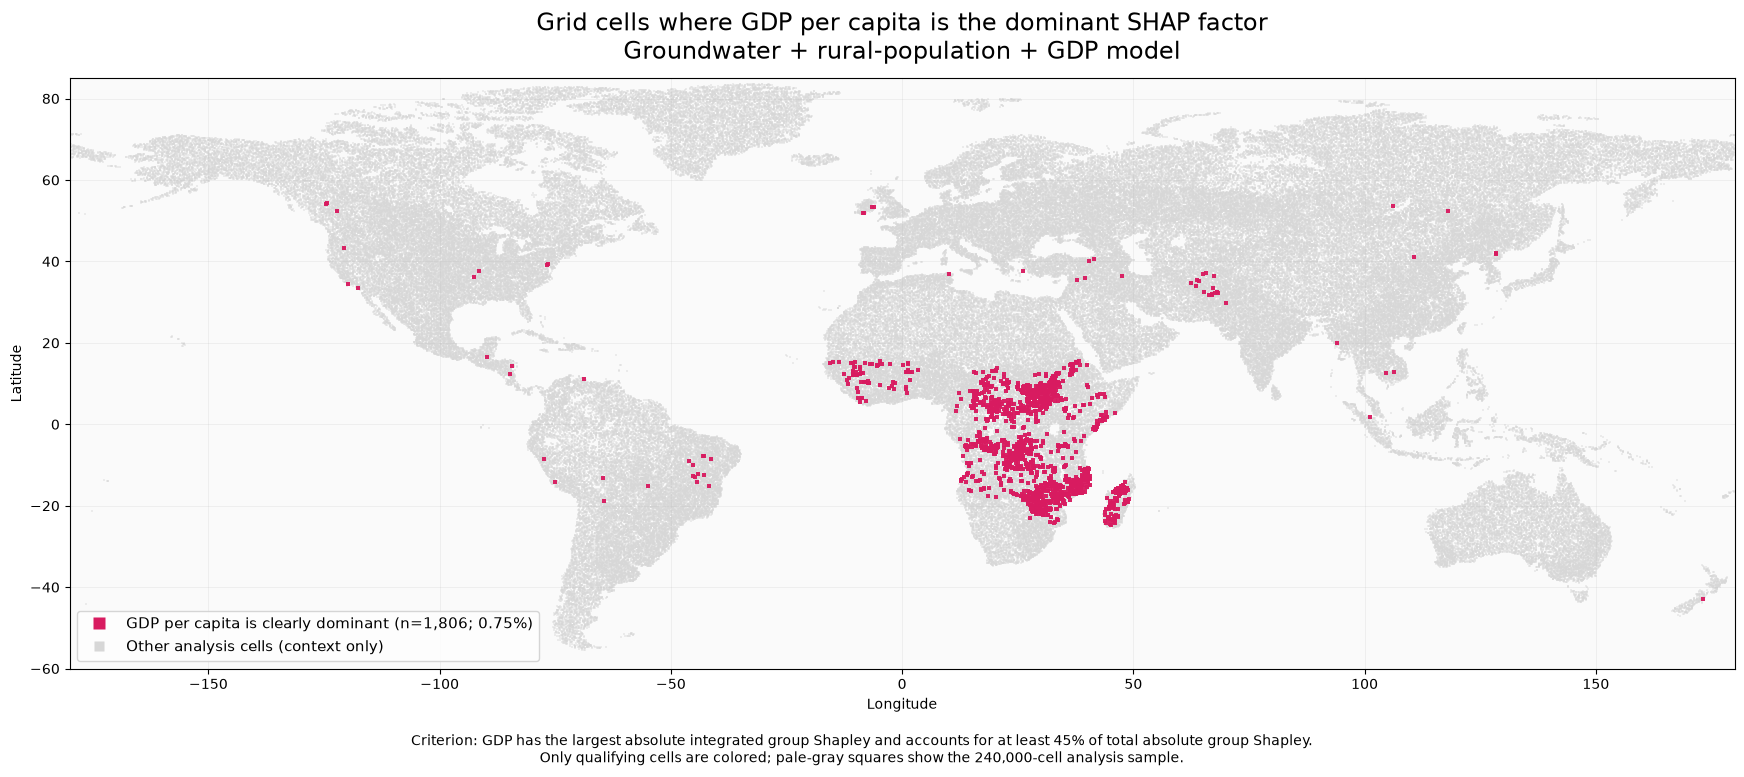

Source: /work/tsuda/GAEZ/CroplandRegression/soil_group_calorie_only_50km_groundwater_rural_population_gdp_target2020/integrated_shapley_archive_bg32_perm32/integrated_group_shapley_by_cell.csv.gz
All analysis cells: 240,000
GDP is the largest absolute group Shapley: 5,946
GDP clearly dominant (share >= 45%): 1,806 (0.752%)
Signed GDP Shapley raises prediction: 18
Signed GDP Shapley lowers prediction: 1,788
Saved figure: /work/tsuda/GAEZ/CroplandRegression/soil_group_calorie_only_50km_groundwater_rural_population_gdp_target2020/gdp_dominant_grids_only_map.png
Saved cells: /work/tsuda/GAEZ/CroplandRegression/soil_group_calorie_only_50km_groundwater_rural_population_gdp_target2020/gdp_dominant_grids_only.csv.gz


,lat,lon,dominant_group_share,dominant_group_signed_shapley,gdp_shap_direction
8,2.291630,43.291576,0.556578,-0.023735,lowers prediction
17,8.208294,25.874918,0.546779,-0.050794,lowers prediction
116,-20.625029,27.791584,0.619845,-0.056590,lowers prediction
372,3.374963,28.708250,0.534820,-0.077042,lowers prediction
430,6.041628,23.458252,0.474443,-0.043653,lowers prediction
524,-6.208367,19.041588,0.483517,-0.059976,lowers prediction
1261,9.374960,30.208250,0.508570,-0.053976,lowers prediction
1317,3.624963,26.958250,0.460208,-0.041842,lowers prediction
1336,-17.708363,27.124918,0.570750,-0.044666,lowers prediction
1586,6.874961,30.874916,0.525300,-0.061933,lowers prediction


5907

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

RESULT_DIR = Path(r"/work/tsuda/GAEZ/CroplandRegression/soil_group_calorie_only_50km_groundwater_rural_population_gdp_target2020")
SOURCE_PATH = (
    RESULT_DIR
    / "integrated_shapley_archive_bg32_perm32"
    / "integrated_group_shapley_by_cell.csv.gz"
)
FIGURE_PATH = RESULT_DIR / "gdp_dominant_grids_only_map.png"
CSV_PATH = RESULT_DIR / "gdp_dominant_grids_only.csv.gz"

MIN_DOMINANCE_SHARE = 0.45
GDP_GROUP = "Economic prosperity"
HIGHLIGHT_COLOR = "#D81B60"
BACKGROUND_COLOR = "#D7D7D7"

columns = [
    "fold", "sample_index", "row", "col", "lat", "lon",
    "presence", "cropland_fraction", "weight",
    "dominant_group", "dominant_group_share",
    "dominant_group_signed_shapley",
    "dominant_group_absolute_shapley",
]
cells = pd.read_csv(SOURCE_PATH, usecols=columns)

gdp_is_largest = cells["dominant_group"].eq(GDP_GROUP)
clear_dominance = cells["dominant_group_share"].ge(MIN_DOMINANCE_SHARE)
gdp_dominant = cells.loc[gdp_is_largest & clear_dominance].copy()

gdp_dominant["gdp_shap_direction"] = np.select(
    [
        gdp_dominant["dominant_group_signed_shapley"] > 0,
        gdp_dominant["dominant_group_signed_shapley"] < 0,
    ],
    ["raises prediction", "lowers prediction"],
    default="zero",
)
gdp_dominant.to_csv(CSV_PATH, index=False, compression="gzip")

n_all = len(cells)
n_gdp_largest = int(gdp_is_largest.sum())
n_clear = len(gdp_dominant)
clear_pct = 100.0 * n_clear / n_all
n_positive = int((gdp_dominant["dominant_group_signed_shapley"] > 0).sum())
n_negative = int((gdp_dominant["dominant_group_signed_shapley"] < 0).sum())

fig, ax = plt.subplots(figsize=(18, 8.2))

# Context only: every analysis cell is pale gray and carries no factor color.
ax.scatter(
    cells["lon"],
    cells["lat"],
    s=1.0,
    marker="s",
    c=BACKGROUND_COLOR,
    alpha=0.42,
    linewidths=0,
    rasterized=True,
    zorder=1,
)

# Only clearly GDP-dominant cells receive a saturated color.
ax.scatter(
    gdp_dominant["lon"],
    gdp_dominant["lat"],
    s=9.0,
    marker="s",
    c=HIGHLIGHT_COLOR,
    alpha=0.96,
    linewidths=0,
    rasterized=True,
    zorder=3,
)

legend_handles = [
    Line2D(
        [0], [0], marker="s", linestyle="none", markersize=8,
        markerfacecolor=HIGHLIGHT_COLOR, markeredgecolor="none",
        label=(
            f"GDP per capita is clearly dominant "
            f"(n={n_clear:,}; {clear_pct:.2f}%)"
        ),
    ),
    Line2D(
        [0], [0], marker="s", linestyle="none", markersize=7,
        markerfacecolor=BACKGROUND_COLOR, markeredgecolor="none",
        label="Other analysis cells (context only)",
    ),
]
ax.legend(
    handles=legend_handles,
    loc="lower left",
    ncol=1,
    frameon=True,
    fontsize=11,
)

ax.set(
    xlim=(-180, 180),
    ylim=(-60, 85),
    xlabel="Longitude",
    ylabel="Latitude",
)
ax.set_facecolor("#FAFAFA")
ax.grid(True, alpha=0.18, linewidth=0.6)
ax.set_title(
    "Grid cells where GDP per capita is the dominant SHAP factor\n"
    "Groundwater + rural-population + GDP model",
    fontsize=17,
    pad=14,
)

criterion = (
    "Criterion: GDP has the largest absolute integrated group Shapley "
    f"and accounts for at least {MIN_DOMINANCE_SHARE:.0%} of total absolute group Shapley.\n"
    "Only qualifying cells are colored; pale-gray squares show the 240,000-cell analysis sample."
)
fig.text(0.5, 0.01, criterion, ha="center", va="bottom", fontsize=10)
fig.subplots_adjust(left=0.06, right=0.985, bottom=0.13, top=0.85)

fig.savefig(FIGURE_PATH, dpi=300, bbox_inches="tight", facecolor="white")
plt.show()

print("Source:", SOURCE_PATH)
print("All analysis cells:", f"{n_all:,}")
print("GDP is the largest absolute group Shapley:", f"{n_gdp_largest:,}")
print(
    f"GDP clearly dominant (share >= {MIN_DOMINANCE_SHARE:.0%}):",
    f"{n_clear:,} ({clear_pct:.3f}%)",
)
print("Signed GDP Shapley raises prediction:", f"{n_positive:,}")
print("Signed GDP Shapley lowers prediction:", f"{n_negative:,}")
print("Saved figure:", FIGURE_PATH)
print("Saved cells:", CSV_PATH)

display(
    gdp_dominant[
        [
            "lat", "lon", "dominant_group_share",
            "dominant_group_signed_shapley", "gdp_shap_direction",
        ]
    ].head(20)
)

# Refresh the result-file index after adding these two outputs.
result_files = sorted(
    str(path.relative_to(RESULT_DIR))
    for path in RESULT_DIR.rglob("*")
    if path.is_file()
)
(RESULT_DIR / "result_file_index.txt").write_text(
    "\n".join(result_files) + "\n",
    encoding="utf-8",
)
